I'll try to extract first singular vector of an given matrix.

In [1]:
import numpy as np
import pandas as pd

In [29]:
np.random.seed(2526)
n = 10

A = np.random.randint(0,10, size = (n,n))
A_norm = np.linalg.norm(A)
A = A / A_norm

x = np.random.randint(0,10, size = n)
x = x / np.linalg.norm(x)

AtA = A.T @ A 

In [32]:
iteration = 50

for _ in range(iteration):
    x = AtA @ x

In [36]:
v1 = x / np.linalg.norm(x)

In [42]:
Av = A @ v1
sing1 = np.linalg.norm(Av)
sing1

np.float64(0.8437604217513496)

In [44]:
np.linalg.svd(A, compute_uv = False)

array([0.84376042, 0.30931525, 0.25502527, 0.22309812, 0.18315524,
       0.15487675, 0.12574987, 0.06414918, 0.01088834, 0.00155386])

In [52]:
uv = (1 / sing1) * A @ v1

In [64]:
newA = A - sing1 * np.outer(uv,v1)

In [65]:
x = np.random.randint(0,10, size = n)
x = x / np.linalg.norm(x)

AtA = newA.T @ newA 

iteration = 50
for _ in range(iteration):
    x = AtA @ x

v2 = x / np.linalg.norm(x)

sing2 = np.linalg.norm(newA @ v2)

In [67]:
sing2

np.float64(0.30931524937528726)

In [182]:
def singValues(A, iteration=30, vectors=False):
    A = A.astype(float)

    R = A.copy()
    u_list = []
    v_list = []
    s_list = []

    max_dm = min(A.shape)

    for _ in range(max_dm):
        x = np.random.randn(A.shape[1])
        x = x / np.linalg.norm(x)

        RtR = R.T @ R

        for _ in range(iteration):
            x = RtR @ x

        v = x / np.linalg.norm(x)
        sigma = np.linalg.norm(R @ v)

        if sigma < 1e-6:
            break

        u = (R @ v) / sigma

        R = R - sigma * np.outer(u, v)

        u_list.append(u)
        v_list.append(v)
        s_list.append(sigma)

    if vectors:
        return u_list, s_list, v_list
    return s_list

In [92]:
newA = np.random.randint(0,10, size = (5,5))
newA

array([[7, 1, 7, 5, 5],
       [2, 2, 4, 0, 4],
       [1, 8, 2, 5, 6],
       [6, 5, 1, 5, 4],
       [6, 6, 0, 2, 7]])

In [93]:
singValues(newA)

[np.float64(21.10286640195979),
 np.float64(7.902864213306853),
 np.float64(4.790152075623868),
 np.float64(3.9761886335961756),
 np.float64(0.6768558853459226)]

In [95]:
np.linalg.svd(newA, compute_uv = False)

array([21.1028664 ,  7.90286421,  4.79015208,  3.97618863,  0.67685589])

---------

Now we will try it on an image

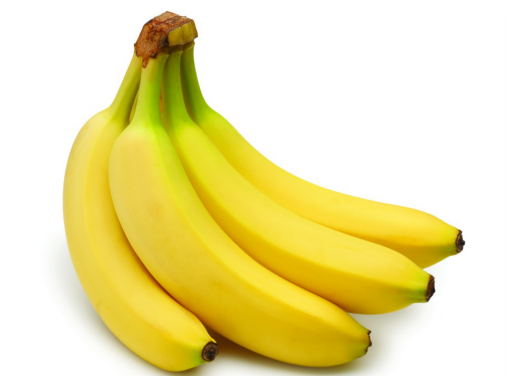

In [97]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Muz.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

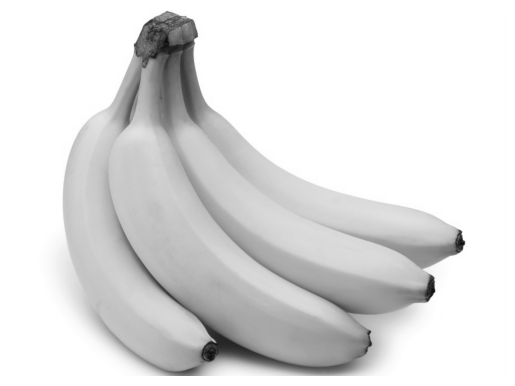

In [195]:
img = Image.open("Muz.jpg")
gray = img.convert("L")

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

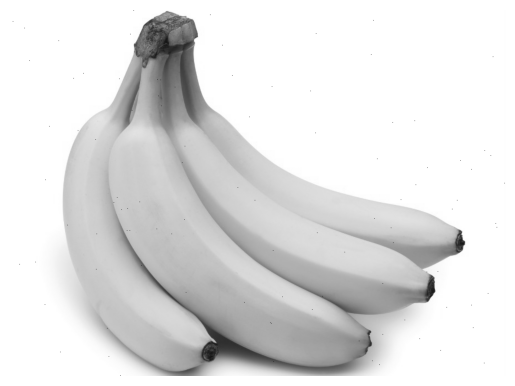

In [240]:
A = np.array(gray)
A.shape

rows = np.random.randint(0, A.shape[0], 100)
cols = np.random.randint(0, A.shape[1], 100)

A[rows, cols] = 0

plt.imshow(A, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()


In [241]:
u,s,v = np.linalg.svd(A)

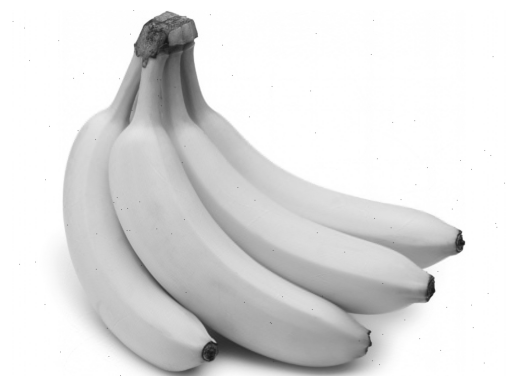

In [259]:
newImage = sum(s[i] * np.outer(u[:, i] , v[i , :]) for i in range(200))
plt.imshow(newImage, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [251]:
ex_gb = A.shape[0] * A.shape[1]

In [257]:
new_gb = (len(v[0 , :]) + len(u[: , 0]) + 1) * 200

In [260]:
new_gb / ex_gb * 100

52.33082706766917

--------

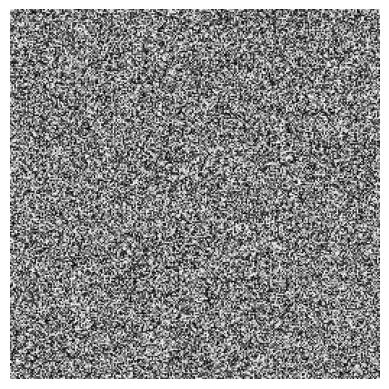

In [262]:
n = 256
A = np.random.randint(0, 256, size=(n, n), dtype=np.uint8)
plt.imshow(A, cmap="gray", vmin=0, vmax=255)

plt.axis("off")

plt.show()

In [263]:
u,s,v = np.linalg.svd(A)

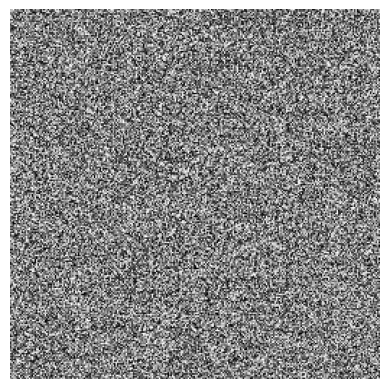

In [272]:
newImage = sum(s[i] * np.outer(u[:, i] , v[i , :]) for i in range(100))
plt.imshow(newImage, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

--------

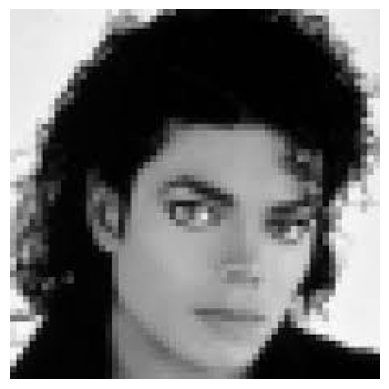

(225, 225)

In [274]:
img = Image.open("MJ.jpg")
gray = img.convert("L")

plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

A = np.array(gray)
A.shape

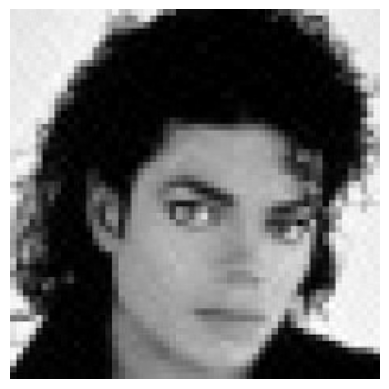

In [279]:
u,s,v = np.linalg.svd(A)
newImage = sum(s[i] * np.outer(u[:, i] , v[i , :]) for i in range(30))
plt.imshow(newImage, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()